# 01 · Data Exploration: AfriSenti Kiswahili

**Task:** 3-way sentiment classification (positive / neutral / negative) of Kiswahili tweets.

**Dataset:** AfriSenti (Muhammad et al., 2023), Kiswahili subset, from the SemEval-2023 Task 12 shared task. The tweets were collected from Twitter and each was annotated by native speakers, with the final label decided by majority vote. We use the official train / validation / test splits.

This notebook answers the following questions:
1. How large is the dataset and how are the labels distributed?
2. What does the text look like, and what noise does it contain?
3. Are there duplicates, leaks between splits or conflicting labels?
4. How much vocabulary in validation and test is never seen in training (the OOV rate)? This motivates the choice of model.

In [1]:
# --- Setup: works both locally and in Google Colab ---
import os, sys
REPO_URL = "https://github.com/Joellate/kiswahili-sentiment-analysis.git"

if "google.colab" in sys.modules:
    if not os.path.exists("kiswahili-sentiment-analysis"):
        !git clone -q $REPO_URL
    %cd kiswahili-sentiment-analysis
    %pip install -q -r requirements.txt
else:
    # running locally from notebooks/
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, "src")
print("Working directory:", os.getcwd())

Working directory: C:\Users\AltTronic\kiswahili-sentiment-analysis


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from data import load_all, LABELS
from preprocessing import clean_text

pd.set_option("display.max_colwidth", 200)
splits = load_all()
df = pd.concat([d.assign(split=s) for s, d in splits.items()], ignore_index=True)
df.head()

,text,label,label_name,split
0,Kwani tanesco wanakataga umeme makusudinadhani kuna changamoto behind zinatakiwa zitatuliwe na sio kutoa matamko,2,negative,train
1,cjawahi kuona content yoyote zaidi ya kuwa analalamika cjawahi kuona akitafuta solution ya tattizo zaid ya kulalamikabasi tutakuwa na Rais wa ajabu huwa mwaka 2045,2,negative,train
2,Bomu lililokuwa limetegwa ndani ya gari likiwalenga wajenzi kutoka Uturuki limelipuka katika eneo la Afgoye kaskazini Magharibi mwa mji mkuu wa Mogadishu Somalia limeua watu wanne polisi wamesema,2,negative,train
3,Kuna video inasambaa mitandaoni jamaa amemfumania mkewe akiwa na jamaa mwingine huku akimlalamikia jamaa akimwambia kw,2,negative,train
4,Viwavijeshi wanapita katika hatua kuu 6 za ukuaji katika hatua yake ya larvae mayai 10001500 hutagwa na larvae mmoja kwa mwezi Hatua pekee inayowezesha kusambaa kwa viwa vijeshi ni kipepeo ambao h...,2,negative,train


## 1. Size and label distribution

In [3]:
dist = pd.crosstab(df.split, df.label_name)[LABELS].loc[["train", "validation", "test"]]
dist["total"] = dist.sum(axis=1)
pct = (pd.crosstab(df.split, df.label_name, normalize="index")[LABELS] * 100).round(1)
display(dist)
display(pct.add_suffix(" %"))

label_name,positive,neutral,negative,total
split,,,,
train,547,1072,191,1810
validation,137,268,48,453
test,224,444,80,748


label_name,positive %,neutral %,negative %
split,,,
test,29.9,59.4,10.7
train,30.2,59.2,10.6
validation,30.2,59.2,10.6


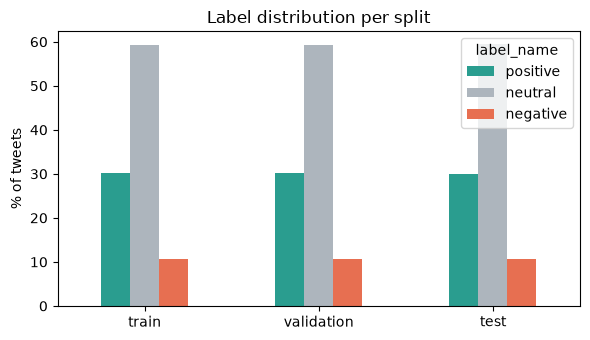

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
(pct.loc[["train", "validation", "test"]]).plot.bar(ax=ax, color=["#2a9d8f", "#adb5bd", "#e76f51"])
ax.set_ylabel("% of tweets"); ax.set_xlabel(""); ax.set_title("Label distribution per split")
plt.xticks(rotation=0); plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/label_distribution.png", dpi=150); plt.show()

**Observation:** the classes are heavily imbalanced. About 59% of tweets are neutral and only about 11% are negative, and the three splits follow the same distribution. A classifier that always predicts *neutral* already reaches about 59% accuracy. **Macro-F1** is therefore our primary metric, which is also the metric of the AfriSenti benchmark.

## 2. Tweet length

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
positive,908.0,17.2,8.4,2.0,11.0,16.0,20.0,44.0
neutral,1784.0,16.5,8.0,2.0,11.0,16.0,20.0,45.0
negative,319.0,18.6,8.5,3.0,13.0,18.0,21.0,44.0


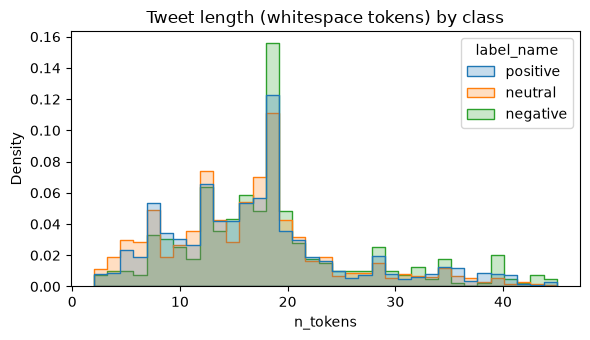

In [5]:
df["n_tokens"] = df.text.str.split().str.len()
display(df.groupby("label_name").n_tokens.describe().loc[LABELS].round(1))
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(data=df, x="n_tokens", hue="label_name", hue_order=LABELS, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Tweet length (whitespace tokens) by class"); plt.tight_layout()
plt.savefig("results/figures/length_by_class.png", dpi=150); plt.show()

## 3. Example tweets per class

In [6]:
for lab in LABELS:
    print(f"=== {lab.upper()} ===")
    for t in splits["train"].query("label_name == @lab").text.sample(5, random_state=1):
        print(" -", t)
    print()

=== POSITIVE ===
 - Watanzania wote Sikukuu njema ya Eid Al Hajj
 - E bwana MC shupavu huu ujumbe wa humu ni zaidi ya inspiration tulimiss sana ngoma za namna hii You nailed
 - Asante kwa kutembelea ukurasa wetu MrMe
 - Leo Oktoba 07 ni kumbukumbu ya siku ya Kuzaliwa kwa Rais Mstaafu wa Jamhuri ya Muungano wa Tanzania katika awamu ya nne M
 - Upendo wa wanafunzi wa shule ya sekondari Chole kijiji cha Chole kwa DC wao aka Dada Hawakutaka niondoke nimewaahidi kurudi

=== NEUTRAL ===
 - Nipashe Ijumaa Februari 7 2020
 - kila tatizo lina utatuzi wake
 - Apps 10 zilizopakuliwa kwa wingi siku ya mwaka mpya Januari 1 2020 kwa watumiaji wa Android 1 WhatsApp 2
 - SAMIA ATOA ANGALIZO KUIKABILI SARATANI Makamu wa Rais Samia Suluhu Hassan amesema tatizo la Saratani kwa Watanzania linaweza kupungua ama kuondokana nalo endapo kutakuwa na tabia ya
 - Are you invited kwenye listening party ya msanii  Nitawasimulia hapa hapa ukali wa ngoma zilozopo kwenye

=== NEGATIVE ===
 - Ile msg ya sizioni siku z

## 4. Noise profile

The released text has **already been stripped** of emojis, punctuation, @mentions and hashtags. Below we count what is left.

In [7]:
patterns = {
    "@mentions": r"@\w+",
    "hashtags": r"#\w+",
    "emoji / non-ASCII": r"[^\x00-\x7f]",
    "punctuation": r"[!?.,:;]",
    "URL fragment (http/www)": r"\b(?:http|www)",
    "HTML-entity residue (gt/amp)": r"\b(?:(?:gt|lt)+|amp|quot)\b",
    "digits": r"\d",
    "letter elongation (aaa)": r"(\w)\1\1",
    "ALL-CAPS word (3+ letters)": r"\b[A-Z]{3,}\b",
}
noise = pd.DataFrame({k: [df.text.str.contains(p, regex=True).sum()] for k, p in patterns.items()}, index=["# tweets"]).T
noise["% of tweets"] = (noise["# tweets"] / len(df) * 100).round(1)
noise

C:\Users\AltTronic\AppData\Local\Temp\ipykernel_30176\2410703683.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  noise = pd.DataFrame({k: [df.text.str.contains(p, regex=True).sum()] for k, p in patterns.items()}, index=["# tweets"]).T


,# tweets,% of tweets
@mentions,0,0.0
hashtags,0,0.0
emoji / non-ASCII,0,0.0
punctuation,0,0.0
URL fragment (http/www),12,0.4
HTML-entity residue (gt/amp),51,1.7
digits,657,21.8
letter elongation (aaa),129,4.3
ALL-CAPS word (3+ letters),479,15.9


**Observation:** emojis, hashtags and punctuation have already been removed, so the strongest surface cues for sentiment (😂, 😡, "!!!") are not available to the model. The remaining noise is:
- leftovers from HTML entities, e.g. `&gt;&gt;` became `gtgt`
- URL fragments
- numbers
- emphatic letter elongation
- inconsistent casing

`src/preprocessing.py` handles each of these, and notebook 02 measures whether cleaning helps.

In [8]:
examples = df[df.text.str.contains(r"\b(?:gt|amp)+\b|(\w)\1\1|\d|http", regex=True)].text.head(8)
pd.DataFrame({"raw": examples.values, "cleaned": [clean_text(t) for t in examples]})

C:\Users\AltTronic\AppData\Local\Temp\ipykernel_30176\3274390838.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  examples = df[df.text.str.contains(r"\b(?:gt|amp)+\b|(\w)\1\1|\d|http", regex=True)].text.head(8)


,raw,cleaned
0,cjawahi kuona content yoyote zaidi ya kuwa analalamika cjawahi kuona akitafuta solution ya tattizo zaid ya kulalamikabasi tutakuwa na Rais wa ajabu huwa mwaka 2045,cjawahi kuona content yoyote zaidi ya kuwa analalamika cjawahi kuona akitafuta solution ya tattizo zaid ya kulalamikabasi tutakuwa na rais wa ajabu huwa mwaka <num>
1,Viwavijeshi wanapita katika hatua kuu 6 za ukuaji katika hatua yake ya larvae mayai 10001500 hutagwa na larvae mmoja kwa mwezi Hatua pekee inayowezesha kusambaa kwa viwa vijeshi ni kipepeo ambao h...,viwavijeshi wanapita katika hatua kuu <num> za ukuaji katika hatua yake ya larvae mayai <num> hutagwa na larvae mmoja kwa mwezi hatua pekee inayowezesha kusambaa kwa viwa vijeshi ni kipepeo ambao ...
2,Waliomua kinyama mtoto wasakwa gt,waliomua kinyama mtoto wasakwa
3,Mwenyekiti wa kijiji cha Kilombero 1 Wilayani Geita amejikuta akisusia kikao kilichoitishwa na Mkuu wa wilaya hiyo ambacho kilikuwa na lengo la kuleta suluhu baada ya wananchi kudaiwa kufunga ofis...,mwenyekiti wa kijiji cha kilombero <num> wilayani geita amejikuta akisusia kikao kilichoitishwa na mkuu wa wilaya hiyo ambacho kilikuwa na lengo la kuleta suluhu baada ya wananchi kudaiwa kufunga ...
4,Wananchi wa mtaa wa Nshinde Wilayani Geita wamelalamikia ubovu wa Barabara inayoelekea fadhili bucha na Mwatulole mkoani hapa kuwa kero kubwa kutokana na ubovu ambao umekuwa ukisababisha gari nyin...,wananchi wa mtaa wa nshinde wilayani geita wamelalamikia ubovu wa barabara inayoelekea fadhili bucha na mwatulole mkoani hapa kuwa kero kubwa kutokana na ubovu ambao umekuwa ukisababisha gari nyin...
5,s Day Msanii wa muziki nchini Tanzania ameendelea kuugulia maumivu ya kutokuwepo kwa Mzazi mwenzake Mchekeshaji Mrembo Boss Martha aliyefariki Septemba 12 2019,s day msanii wa muziki nchini tanzania ameendelea kuugulia maumivu ya kutokuwepo kwa mzazi mwenzake mchekeshaji mrembo boss martha aliyefariki septemba <num> <num>
6,Mama mzazi wa mwandishi wa Habari za uchunguzi anayeshikiliwa na Dola Erick Kabendera Verdiana Mjwahuzi amefariki dunia Desemba 312019 Taarifa za kufariki kwake zimepatikana alfajiri ya leo Januar...,mama mzazi wa mwandishi wa habari za uchunguzi anayeshikiliwa na dola erick kabendera verdiana mjwahuzi amefariki dunia desemba <num> taarifa za kufariki kwake zimepatikana alfajiri ya leo januari...
7,VIDEOWatu 6 wamepoteza maisha na wengine 30 kujeruhiwa kwenye mlipuko uliotokea leo katika kiwanda cha kemikali mashariki mwa China CGTN,videowatu <num> wamepoteza maisha na wengine <num> kujeruhiwa kwenye mlipuko uliotokea leo katika kiwanda cha kemikali mashariki mwa china cgtn


## 5. Duplicates, leakage and label conflicts

In [9]:
dups = df[df.text.duplicated(keep=False)].sort_values("text")
print("Duplicated tweet texts (all rows):", len(dups))
train_set = set(splits["train"].text)
print("Validation tweets also in train:", splits["validation"].text.isin(train_set).sum())
print("Test tweets also in train:      ", splits["test"].text.isin(train_set).sum())
conflicts = dups.groupby("text").label_name.nunique()
print("Duplicated texts with CONFLICTING labels:", (conflicts > 1).sum())
dups[dups.text.isin(conflicts[conflicts > 1].index)][["split", "label_name", "text"]]

Duplicated tweet texts (all rows): 21
Validation tweets also in train: 3
Test tweets also in train:       0
Duplicated texts with CONFLICTING labels: 3


,split,label_name,text
1308,train,positive,Habari tunaomba namba yako DM kwa msaada zaidiKA
1577,train,positive,Habari tunaomba namba yako DM kwa msaada zaidiKA
322,train,neutral,Habari tunaomba namba yako DM kwa msaada zaidiKA
1241,train,neutral,Tunafunga sana kumi na nusu jionikaribu sana
1749,train,positive,Tunafunga sana kumi na nusu jionikaribu sana
1222,train,neutral,Upo eneo gani mteja tunaomba details vizuri ili tuweze kufuatilia
1430,train,positive,Upo eneo gani mteja tunaomba details vizuri ili tuweze kufuatilia


**Observation:** the amount of leakage is negligible. No test tweet appears in train, and only 3 validation tweets do. However, some identical tweets carry *different* labels. This is direct evidence of **annotation noise**, and it caps the score any model can reach. We keep the official splits unchanged so that our results stay comparable with the benchmark.

## 6. Vocabulary and out-of-vocabulary (OOV) rate

Kiswahili is agglutinative. Prefixes mark subject, tense and object (e.g. *ni-li-ku-penda* = "I loved you"), so a single verb root appears in many surface forms. On top of that, tweets use non-standard spellings (e.g. *hzi* for *hizi*). Together these make many word forms rare.

In [10]:
tok = lambda s: clean_text(s).split()
train_vocab = Counter(w for t in splits["train"].text for w in tok(t))
print(f"Train vocabulary size: {len(train_vocab):,} word types")
print(f"Word types seen only once in train: {sum(c == 1 for c in train_vocab.values()) / len(train_vocab):.1%}")
for s in ["validation", "test"]:
    toks = [w for t in splits[s].text for w in tok(t)]
    types = set(toks)
    print(f"{s:10s} token OOV rate: {np.mean([w not in train_vocab for w in toks]):.1%} | "
          f"type OOV rate: {np.mean([w not in train_vocab for w in types]):.1%}")

Train vocabulary size: 8,820 word types
Word types seen only once in train: 69.4%
validation token OOV rate: 19.6% | type OOV rate: 43.9%
test       token OOV rate: 20.5% | type OOV rate: 50.9%


**Observation:** with only about 1,800 training tweets, a large share of the test tokens never appear in training. This sets up the main hypotheses that the experiments in notebooks 02 to 04 test:
- **Character n-grams** should beat word n-grams, because they share information between inflected forms of the same root.
- **Pretrained multilingual / Africa-centric Transformers** (AfroXLMR, XLM-R, mBERT) should help most. They bring Swahili knowledge learned from far larger corpora, and their subword tokenisers avoid the OOV problem entirely.

## 7. Most class-indicative words

We use the smoothed log-odds ratio of each word in one class against all the other classes, keeping words with frequency ≥ 5.

In [11]:
def top_words(label, k=15, min_count=5):
    in_c = Counter(w for t in splits["train"].query("label_name == @label").text for w in set(tok(t)))
    out_c = Counter(w for t in splits["train"].query("label_name != @label").text for w in set(tok(t)))
    n_in, n_out = sum(in_c.values()), sum(out_c.values())
    scores = {w: np.log((in_c[w] + 1) / n_in) - np.log((out_c[w] + 1) / n_out)
              for w in in_c if in_c[w] + out_c[w] >= min_count}
    return [w for w, _ in sorted(scores.items(), key=lambda x: -x[1])[:k]]

pd.DataFrame({lab: top_words(lab) for lab in LABELS})

,positive,neutral,negative
0,idara,anasema,amefariki
1,njema,odds,makubwa
2,kumbukumbu,kiingereza,polisi
3,upendo,ndiyo,mtaa
4,piga,wakiwa,hawataki
5,tunakutakia,majibu,robert
6,kitabu,wazi,kisheria
7,baraka,nani,kosa
8,mchango,mpk,mkoani
9,mungu,liverpool,jeshi


## 8. Code-switching

Swahili tweets often mix in English. We estimate how often by counting tweets that contain common English function words.

In [12]:
english = {"the", "and", "is", "of", "to", "in", "for", "you", "my", "this", "that", "with", "are", "on", "be", "it", "we", "i", "your", "so"}
df["has_english"] = df.text.str.lower().str.split().apply(lambda ws: any(w in english for w in ws))
print(f"Tweets with English function words: {df.has_english.mean():.1%}")
display(df.groupby("label_name").has_english.mean().loc[LABELS].round(3))
df[df.has_english].text.head(5).tolist()

Tweets with English function words: 4.9%


label_name
positive    0.045
neutral     0.048
negative    0.069
Name: has_english, dtype: float64

['Imekuwa too muchwatu wanashindwa hata kusheherekea maisha yao kwa amanimtu unampost mke wake kumpongeza wameoana we unakuja kutukana kwenye comments watu hata huwajui',
 'So wazee wanawanyanyasa hadi wajeda sio sisi raia tu sijapenda Me nawaaminia sana wajedasiku za mbeleni najua hamtotuangusha wanetu na mtakuwa mmechukizwa sana ila basi tu',
 'Humu ndani kuna watu wana madini mengi sana shida ni kwamba ukiwaomba waziteme watakuzungusha Bora uweke notification on',
 'Nimepokea kwa masikitiko makubwa taarifa za kifo cha Rais Mstaafu na Baba wa Taifa la Zimbabwe Mzee Robert Mugabe Afrika i',
 'Nchi ya drama na matukio Ila hii kama ikidhihirika ni kweli basi ni kashfa kubwa sana kitaifa Mark my words Maswali ha']

## Summary

| Finding | Implication |
|---|---|
| Only 3,011 tweets, with 1,810 for training | Learning from scratch will be hard, which favours pretrained models |
| Imbalanced: 59% neutral, 30% positive, 11% negative | Use macro-F1 and try class weighting |
| Emojis and punctuation already removed | Sentiment has to come from the words alone |
| Identical tweets with conflicting labels | Annotation noise limits the best achievable score |
| High OOV rate, agglutinative morphology, non-standard spelling | Expect character / subword models to beat word models |
| Code-switching with English | Multilingual pretrained models may handle it better |